In [15]:

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import math

import numpy as np
import matplotlib.pyplot as plt

In [16]:
#!pip install torch==2.8.0

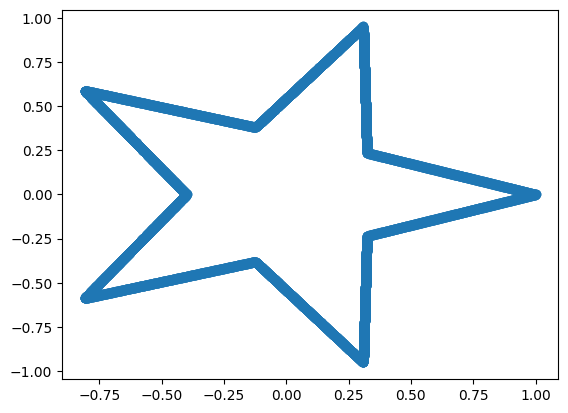

In [17]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [18]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

    beta_min = 0.1
    beta_max = 20.0

In [ ]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)
    


In [20]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [21]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [22]:
def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def integral_beta(t, config):
    return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2

In [23]:
class VPTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            bs = batch.shape[0]

            t = torch.rand(bs, 1, device=self.device)

            int_beta = integral_beta(t, self.config)

            exp_neg_int = torch.exp(-int_beta)
            exp_neg_half_int = torch.exp(-0.5 * int_beta)
            mean_coef = exp_neg_half_int
            std_coef = torch.sqrt(1.0 - exp_neg_int)

            z = torch.randn_like(batch)
            x_t = mean_coef * batch + std_coef * z

            pred_z = self.model(x_t, t)
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * bs

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [24]:
config = Config()
trainer = VPTrainer(config)

In [25]:
trainer.run()

Loss: 0.8279584444999695
Loss: 0.17381233637332916
Loss: 0.16599102182388306
Loss: 0.16515538713932038
Loss: 0.16333387525081636
Loss: 0.16832396368980407
Loss: 0.1744655074596405
Loss: 0.16769040937423707
Loss: 0.1685217406272888
Loss: 0.16195725634098054
Loss: 0.15659396524429323
Loss: 0.16111088809967042
Loss: 0.16122639491558075
Loss: 0.15193489079475403
Loss: 0.15112819592952728
Loss: 0.1612850070476532
Loss: 0.1458571738243103
Loss: 0.16328489382266997
Loss: 0.16247404310703278
Loss: 0.15328435702323914


In [26]:
def sample_vp(model, config, num_samples=1000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):

            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t, config)
            int_beta = integral_beta(t, config)

            std_coef = torch.sqrt(1.0 - torch.exp(-int_beta))

            pred_noise = model(x, t)

            score = -pred_noise / (std_coef + 1e-8)

            drift = (0.5 * beta * x + beta * score) * dt
            diffusion = torch.sqrt(beta) * torch.randn_like(x) * (dt ** 0.5)

            x = x + drift + diffusion

    return x.cpu().numpy()

In [27]:
samples = sample_vp(trainer.model, trainer.config, 1000)

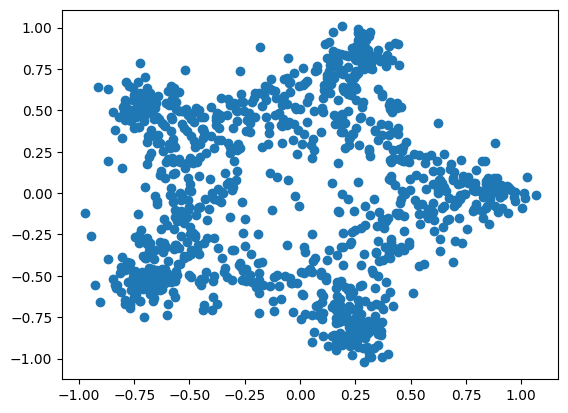

In [28]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()